In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from qiskit_ibm_provider import IBMProvider
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
from qiskit.primitives import Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_provider import IBMProvider
from qiskit.quantum_info import SparsePauliOp
import os
from dotenv import load_dotenv


In [33]:
import pandas as pd

# Load CSV data
wind_data = pd.read_csv('wind_data.csv')
# Example columns: x, y, u, v

# Map to grid (assuming your grid matches the data points)
u_field = wind_data.pivot(index='y', columns='x', values='u').values
v_field = wind_data.pivot(index='y', columns='x', values='v').values

In [34]:
load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")
provider = IBMProvider(token=token)
backend = provider.get_backend('ibm_brisbane')

In [35]:
Lx, Ly = 1.0, 1.0
Nx, Ny = u_field.shape[1], u_field.shape[0]  # Use shape from real data
dx, dy = Lx/Nx, Ly/Ny

nu = 1e-5
rho = 1.0
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

# u_field and v_field already set from real data
p_field = np.zeros((Ny, Nx))
k_field = np.ones((Ny, Nx)) * 0.01
epsilon_field = np.ones((Ny, Nx)) * 0.001


In [36]:
def compute_turbulent_viscosity(k, epsilon):
    C_mu = 0.09
    return C_mu * k**2 / (epsilon + 1e-10)

def compute_rhs(u, v, p, nu_t):
    rhs_u, rhs_v = np.zeros_like(u), np.zeros_like(v)
    for j in range(1, Ny-1):
        for i in range(1, Nx-1):
            mu_eff = nu + nu_t[j, i]
            rhs_u[j, i] = mu_eff * ((u[j, i+1] - 2*u[j, i] + u[j, i-1]) / dx**2 +
                                     (u[j+1, i] - 2*u[j, i] + u[j-1, i]) / dy**2)
            rhs_v[j, i] = mu_eff * ((v[j, i+1] - 2*v[j, i] + v[j, i-1]) / dx**2 +
                                     (v[j+1, i] - 2*v[j, i] + v[j-1, i]) / dy**2)
    return rhs_u, rhs_v

In [37]:
def visualize_flow(u, v, title="Velocity Field"):
    plt.figure(figsize=(8, 6))
    plt.quiver(X, Y, u, v, color='blue')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


In [38]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE
from qiskit_algorithms.utils import algorithm_globals

# Define a simple 2x2 system (placeholder for pressure solve): A x = b
A = np.array([[3, 1], [1, 2]])
# For quantum, we need a Hermitian operator. Let's use A as a Hamiltonian.
H = SparsePauliOp.from_operator(A)

# Estimator and ansatz setup
estimator = Estimator()
ansatz = TwoLocal(rotation_blocks='ry', entanglement_blocks='cz', reps=1)
optimizer = COBYLA(maxiter=100)
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

algorithm_globals.random_seed = 42
result = vqe.compute_minimum_eigenvalue(H)
print("Quantum Solution (approx. eigenvalue):", result.eigenvalue.real)

Quantum Solution (approx. eigenvalue): 1.3819660287759086


C:\Users\sanje\AppData\Local\Temp\ipykernel_3320\5786738.py:14: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


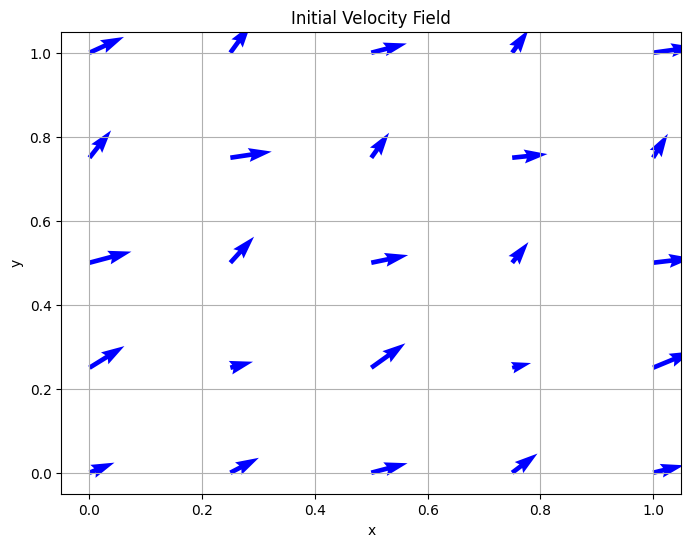

In [39]:
nu_t = compute_turbulent_viscosity(k_field, epsilon_field)
rhs_u, rhs_v = compute_rhs(u_field, v_field, p_field, nu_t)
visualize_flow(u_field, v_field, title="Initial Velocity Field")